# Exercise 1: Vision Transformers for Image Classification

**Advanced Deep Learning — Winter 2025/2026**

---

In this notebook, we will implement and train **Vision Transformers (ViT)** and **Cross-Attention Multi-Scale Vision Transformers (CrossViT)** for image classification on CIFAR-10.

The notebook is structured as follows:

| Exercise | Topic |
|----------|-------|
| 1.1 | PyTorch project structure: data loading, augmentation, training loop |
| 1.2 | Vision Transformer (ViT): self-attention for image patches |
| 1.3 | CrossViT: dual-branch cross-attention multi-scale ViT |
| 1.4 | *(Optional)* Visualizing attention maps |

### Recommended Background Reading
- **ViT paper**: [An Image is Worth 16x16 Words](https://arxiv.org/abs/2010.11929) (Dosovitskiy et al., ICLR 2021)
- **CrossViT paper**: [Cross-Attention Multi-Scale Vision Transformer](https://arxiv.org/abs/2103.14899) (Chen et al., 2021)

## Setup

First, let's install and import all required packages.

In [ ]:
# Install dependencies if needed
# !pip install torch torchvision einops tqdm matplotlib

In [1]:
import os
import torch
from torch import nn, einsum
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch import optim
from tqdm.notebook import tqdm
import numpy as np
import matplotlib.pyplot as plt
from einops import rearrange, repeat
from einops.layers.torch import Rearrange

# Reproducibility
torch.manual_seed(1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


---

## Exercise 1.1 — PyTorch Project Structure

### 1.1.1 The CIFAR-10 Dataset

[CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) consists of 60,000 color images (32×32 pixels) distributed evenly across 10 classes:

> ✈️ airplane · 🚗 automobile · 🐦 bird · 🐱 cat · 🦌 deer · 🐶 dog · 🐸 frog · 🐴 horse · 🚢 ship · 🚚 truck

The dataset is split into **50,000 training** and **10,000 test** images.

### 1.1.2 Data Augmentation

Data augmentation is a regularization technique that artificially enlarges the training set by applying random, label-preserving transformations to each image. This reduces overfitting, especially for small datasets.

For CIFAR-10 we use a standard augmentation pipeline:
- **RandomCrop(32, padding=4)** — pads the image by 4 pixels and crops a random 32×32 region
- **RandomHorizontalFlip()** — randomly mirrors the image left-right
- **Normalize(mean, std)** — standardizes each channel using ImageNet statistics (a good proxy even for CIFAR)

During **validation and testing**, we skip the random augmentations and only apply normalization — we want a deterministic evaluation.

In [2]:
# --- Data Transforms ---
# ImageNet mean/std are a good approximation for CIFAR-10 too
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),       # augmentation
    transforms.RandomHorizontalFlip(),           # augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# --- Load Dataset ---
dataset = datasets.CIFAR10('./data', download=True, train=True,  transform=transform_train)
testset = datasets.CIFAR10('./data', download=True, train=False, transform=transform_test)

# 90/10 train/val split
n_train = int(len(dataset) * 0.9)
trainset, valset = torch.utils.data.random_split(dataset, [n_train, len(dataset) - n_train])

# IMPORTANT: override transforms on valset so it uses test (no augmentation) transforms
valset.dataset.transform = transform_test

trainloader = DataLoader(trainset, batch_size=64, shuffle=True,  num_workers=2)
valloader   = DataLoader(valset,   batch_size=64, shuffle=False, num_workers=2)
testloader  = DataLoader(testset,  batch_size=64, shuffle=False, num_workers=2)

CLASSES = testset.classes
print(f"Train: {len(trainset)} | Val: {len(valset)} | Test: {len(testset)}")
print(f"Classes: {CLASSES}")

Files already downloaded and verified
Files already downloaded and verified
Train: 45000 | Val: 5000 | Test: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


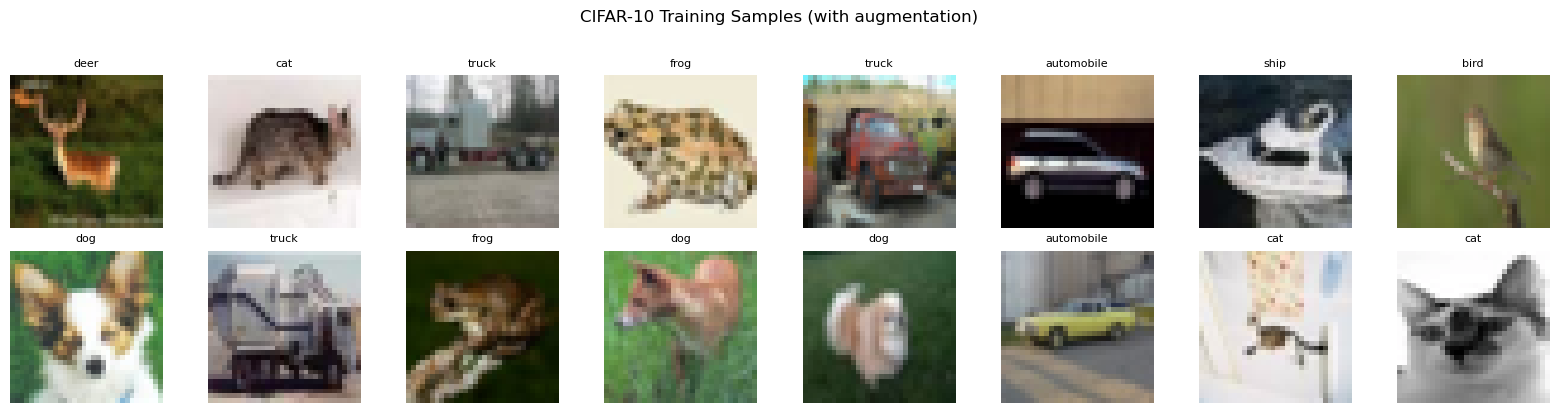

In [3]:
# Visualize some samples from the training set
def unnormalize(img_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """Reverse the normalization for display."""
    img = img_tensor.clone()
    for t, m, s in zip(img, mean, std):
        t.mul_(s).add_(m)
    return img.clamp(0, 1)

imgs, labels = next(iter(trainloader))
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    img = unnormalize(imgs[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(CLASSES[labels[i]], fontsize=8)
    ax.axis('off')
plt.suptitle('CIFAR-10 Training Samples (with augmentation)', y=1.02)
plt.tight_layout()
plt.show()

### 1.1.3 Training and Evaluation Loops

The training loop iterates over batches, computes the **cross-entropy loss**, and updates model weights via **SGD with momentum**.

The evaluation loop runs in `torch.no_grad()` mode (no gradient computation) and reports average loss and accuracy.

In [4]:
def train_epoch(model, trainloader, optimizer, criterion, device, epoch):
    model.train()
    pbar = tqdm(trainloader, desc=f'Train Epoch {epoch}', leave=False)
    for batch_idx, (data, target) in enumerate(pbar):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target) / len(output)
        loss.backward()
        optimizer.step()
        if batch_idx % 10 == 0:
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})


def evaluate(model, loader, criterion, device, split="Val"):
    model.eval()
    total_loss, correct = 0, 0
    pbar = tqdm(loader, desc=f'{split} Set', leave=False)
    with torch.no_grad():
        for data, target in pbar:
            data, target = data.to(device), target.to(device)
            output = model(data)
            total_loss += criterion(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    avg_loss = total_loss / len(loader.dataset)
    accuracy = 100. * correct / len(loader.dataset)
    print(f'  [{split}] Loss: {avg_loss:.4f} | Accuracy: {correct}/{len(loader.dataset)} ({accuracy:.1f}%)')
    return accuracy


def run_training(model, trainloader, valloader, testloader, 
                 epochs=5, lr=0.003, momentum=0.9, save_path=None):
    """Full training pipeline with best-model checkpointing."""
    criterion = nn.CrossEntropyLoss(reduction="sum")
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum)
    model.to(device)

    best_acc = 0.0
    history = {'train_loss': [], 'val_acc': []}
    os.makedirs('models', exist_ok=True)

    for epoch in range(1, epochs + 1):
        print(f"\nEpoch {epoch}/{epochs}")
        train_epoch(model, trainloader, optimizer, criterion, device, epoch)
        val_acc = evaluate(model, valloader, criterion, device, split="Val")
        history['val_acc'].append(val_acc)

        if val_acc > best_acc:
            best_acc = val_acc
            print(f"  ✓ New best val accuracy: {val_acc:.2f}%")
            if save_path:
                torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                            'optimizer_state_dict': optimizer.state_dict(),
                            'accuracy': best_acc}, save_path)

    # Load best model and evaluate on test set
    if save_path and os.path.exists(save_path):
        ckpt = torch.load(save_path, weights_only=True)
        model.load_state_dict(ckpt['model_state_dict'])
        print(f"\nLoaded best model from epoch {ckpt['epoch']} (val acc: {ckpt['accuracy']:.2f}%)")

    print("\n--- Final Test Set Evaluation ---")
    test_acc = evaluate(model, testloader, criterion, device, split="Test")
    return history, test_acc

### 1.1.4 Baseline: ResNet-18

Before implementing transformers, let's establish a baseline using **ResNet-18** — a classic convolutional architecture with residual connections.

In [5]:
# ResNet-18 baseline (no pretrained weights)
resnet = models.resnet18(weights=None)

# Count parameters
n_params = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
print(f"ResNet-18 parameters: {n_params:,}")

# Uncomment to train:
# history_r18, test_acc_r18 = run_training(
#     resnet, trainloader, valloader, testloader,
#     epochs=10, lr=0.003, save_path='models/checkpoint_r18.pt'
# )

ResNet-18 parameters: 11,689,512


---

## Exercise 1.2 — Vision Transformer (ViT)

### Background: The Transformer Architecture

Transformers were originally designed for NLP (Vaswani et al., 2017 — *Attention Is All You Need*). The central idea is the **self-attention** mechanism, which lets every token in a sequence attend to every other token, capturing long-range dependencies.

**ViT** (Dosovitskiy et al., 2021) applies a standard Transformer encoder directly to sequences of image patches — treating each patch as a "word".

---

### 2.1 From Images to Tokens: Patch Embedding

Given an image $\mathbf{x} \in \mathbb{R}^{H \times W \times C}$, we split it into $N = \frac{HW}{P^2}$ non-overlapping patches of size $P \times P$. Each patch is flattened and linearly projected to a $D$-dimensional embedding.

$$\mathbf{z}_0 = [\mathbf{x}_{\text{cls}};\, \mathbf{x}^1_p \mathbf{E};\, \mathbf{x}^2_p \mathbf{E};\, \ldots;\, \mathbf{x}^N_p \mathbf{E}] + \mathbf{E}_{\text{pos}}$$

Key components:
- **Linear projection** $\mathbf{E} \in \mathbb{R}^{(P^2 \cdot C) \times D}$: maps each flattened patch to $D$ dimensions
- **[CLS] token** $\mathbf{x}_{\text{cls}}$: a learnable token prepended to the sequence, whose final representation is used for classification
- **Positional embedding** $\mathbf{E}_{\text{pos}} \in \mathbb{R}^{(N+1) \times D}$: learned position encodings, since self-attention is permutation-invariant

For our CIFAR-10 setup: $H=W=32$, $P=8$, so $N = (32/8)^2 = 16$ patches plus 1 CLS token = **17 tokens** total.

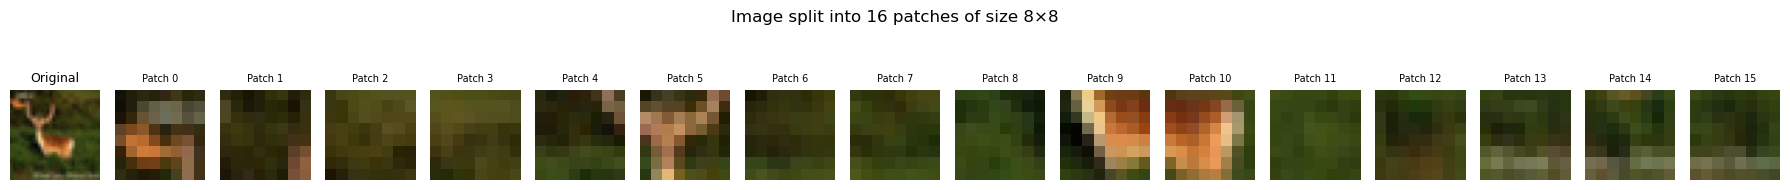

Each patch is flattened to: 192 values, then projected to dim D


In [6]:
# Visualize how ViT patches a 32x32 CIFAR image
PATCH_SIZE = 8
IMAGE_SIZE = 32
N_PATCHES  = (IMAGE_SIZE // PATCH_SIZE) ** 2  # = 16

sample_img = unnormalize(imgs[0])  # un-normalize for display

fig, axes = plt.subplots(1, N_PATCHES + 1, figsize=(18, 2))
axes[0].imshow(sample_img.permute(1, 2, 0).numpy())
axes[0].set_title('Original', fontsize=9)
axes[0].axis('off')

patches = sample_img.unfold(1, PATCH_SIZE, PATCH_SIZE).unfold(2, PATCH_SIZE, PATCH_SIZE)
# shape: [C, n_h, n_w, P, P]  -> reshape to [n_h*n_w, C, P, P]
patches = patches.contiguous().view(3, -1, PATCH_SIZE, PATCH_SIZE).permute(1, 0, 2, 3)

for i, ax in enumerate(axes[1:]):
    ax.imshow(patches[i].permute(1, 2, 0).numpy())
    ax.set_title(f'Patch {i}', fontsize=7)
    ax.axis('off')

plt.suptitle(f'Image split into {N_PATCHES} patches of size {PATCH_SIZE}×{PATCH_SIZE}', y=1.05)
plt.tight_layout()
plt.show()
print(f"Each patch is flattened to: {3 * PATCH_SIZE**2} values, then projected to dim D")

### 2.2 Multi-Head Self-Attention (MSA)

The core of the Transformer is **Multi-Head Self-Attention**. For a sequence of $N$ tokens $\mathbf{z} \in \mathbb{R}^{N \times D}$:

1. **Project** to queries, keys, and values:  
   $\mathbf{Q} = \mathbf{z}\mathbf{W}_Q, \quad \mathbf{K} = \mathbf{z}\mathbf{W}_K, \quad \mathbf{V} = \mathbf{z}\mathbf{W}_V$

2. **Compute attention scores** (scaled dot-product):  
   $\mathbf{A} = \text{softmax}\!\left(\frac{\mathbf{Q}\mathbf{K}^\top}{\sqrt{d_k}}\right)$

3. **Aggregate values**:  
   $\text{SA}(\mathbf{z}) = \mathbf{A}\mathbf{V}$

**Multi-head** attention runs $h$ heads in parallel with dimension $d_k = D/h$ each, then concatenates and projects:
$$\text{MSA}(\mathbf{z}) = [\text{SA}_1(\mathbf{z});\, \ldots;\, \text{SA}_h(\mathbf{z})]\, \mathbf{W}_{\text{out}}$$

The $\sqrt{d_k}$ scaling prevents the dot products from growing too large (which would push the softmax into saturated regions with tiny gradients).

**Why is this useful for images?** Unlike convolutions, which only look at local neighborhoods, self-attention can directly relate any two patches — even far apart — in a single layer.

In [7]:
# Helper functions shared by ViT and CrossViT
def pair(t):
    return t if isinstance(t, tuple) else (t, t)


class PreNorm(nn.Module):
    """Apply LayerNorm before a sub-layer (Pre-LN formulation)."""
    def __init__(self, dim, fn):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.fn = fn

    def forward(self, x, **kwargs):
        return self.fn(self.norm(x), **kwargs)


class FeedForward(nn.Module):
    """Position-wise Feed-Forward Network: Linear -> GELU -> Dropout -> Linear -> Dropout."""
    def __init__(self, dim, hidden_dim, dropout=0.):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)

### Implementation of Multi-Head Self-Attention

The attention class computes multi head self attention. The `forward` method follows these steps:

1. Project input `x` (and optionally `context`) to Q, K, V with separate linear layers  
2. Reshape to `[batch, heads, tokens, dim_head]`  
3. Compute scaled dot-product attention: `softmax(Q @ K.T / sqrt(dim_head))`  
4. Apply dropout to the attention weights  
5. Multiply by V and reshape back  
6. Store the attention map in `self.attn` (needed for visualization in Ex. 1.4)  

The `context` argument enables **cross-attention**: Q comes from `x`, but K and V come from `context`.

<div align="center">

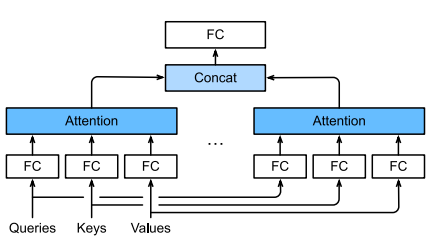

</div>

In [8]:
class Attention(nn.Module):
    """
    Multi-Head (Self/Cross) Attention.

    Input shape:  [batch, n_tokens, dim]
    Output shape: [batch, n_tokens, dim]
    """
    def __init__(self, dim, heads=8, dim_head=64, dropout=0.):
        super().__init__()
        self.heads = heads
        self.scale  = np.sqrt(dim_head)          # 1/sqrt(d_k) scaling factor
        self.softmax = nn.Softmax(dim=-1)
        self.dropout = nn.Dropout(dropout)

        # Q, K, V projections  (bias=False, as is common in ViT implementations)
        self.q = nn.Linear(dim, dim_head * heads, bias=False)
        self.k = nn.Linear(dim, dim_head * heads, bias=False)
        self.v = nn.Linear(dim, dim_head * heads, bias=False)

        # Output projection back to original dim
        self.output = nn.Sequential(
            nn.Linear(dim_head * heads, dim),
            nn.Dropout(dropout)
        )

        self.attn = None  # stored for visualization

    def forward(self, x, context=None, kv_include_self=False):
        # x: [b, n, dim]
        b, n, _, h = *x.shape, self.heads

        if context is None:
            context = x
        if kv_include_self:
            # For cross-attention: prepend the CLS token to the context tokens
            context = torch.cat((x, context), dim=1)

        # --- YOUR CODE HERE ---
        # 1. Project to Q, K, V
        q = self.q(x)        # [b, n, h*d]
        k = self.k(context)  # [b, m, h*d]
        v = self.v(context)  # [b, m, h*d]

        # 2. Split into heads: [b, n, h*d] -> [b, h, n, d]
        q = rearrange(q, 'b n (h d) -> b h n d', h=h)
        k = rearrange(k, 'b m (h d) -> b h m d', h=h)
        v = rearrange(v, 'b m (h d) -> b h m d', h=h)

        # 3. Scaled dot-product attention: [b, h, n, m]
        dots = einsum('b h n d, b h m d -> b h n m', q, k) / self.scale
        attn = self.dropout(self.softmax(dots))

        # 4. Store for visualization
        self.attn = attn

        # 5. Aggregate values: [b, h, n, d]
        out = einsum('b h n m, b h m d -> b h n d', attn, v)

        # 6. Merge heads and project: [b, n, dim]
        out = rearrange(out, 'b h n d -> b n (h d)')
        out = self.output(out)
        # ----------------------

        return out

### 2.3 Transformer Encoder Block

Each Transformer **encoder layer** consists of:
1. **Pre-LN Multi-Head Self-Attention** with residual connection
2. **Pre-LN Feed-Forward Network** with residual connection

$$\mathbf{y}_\ell = \mathbf{z}_{\ell-1} + \text{MSA}(\text{LN}(\mathbf{z}_{\ell-1}))$$
$$\mathbf{z}_\ell = \mathbf{y}_\ell + \text{FFN}(\text{LN}(\mathbf{y}_\ell))$$

The **residual connections** allow gradients to flow back easily through many layers.

The **FFN** expands the dimension by a factor $r$ (typically 4), applies a GELU nonlinearity, then projects back down:
$$\text{FFN}(\mathbf{z}) = \text{GELU}(\mathbf{z}\mathbf{W}_1 + \mathbf{b}_1)\mathbf{W}_2 + \mathbf{b}_2$$

The images illustrates the overall structure of the Transformer Encoder:

<div align="center">

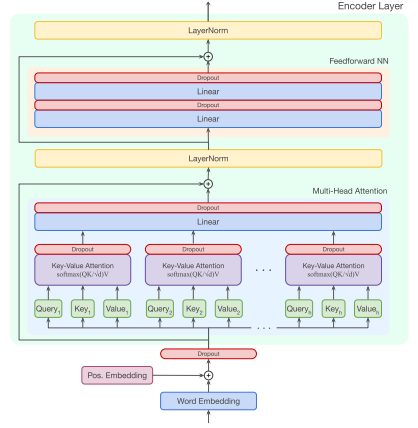

</div>

In [9]:
class Transformer(nn.Module):
    """Stack of Transformer encoder layers."""
    def __init__(self, dim, depth, heads, dim_head, mlp_dim, dropout=0.):
        super().__init__()
        self.layers = nn.ModuleList([])
        for _ in range(depth):
            self.layers.append(nn.ModuleList([
                PreNorm(dim, Attention(dim, heads=heads, dim_head=dim_head, dropout=dropout)),
                PreNorm(dim, FeedForward(dim, mlp_dim, dropout=dropout))
            ]))

    def forward(self, x):
        for attn, ff in self.layers:
            x = attn(x) + x  # residual
            x = ff(x)   + x  # residual
        return x

### 2.4 Image Embedder

The `ImageEmbedder` module handles the full image-to-token conversion pipeline:
1. Rearrange image patches into a flat sequence
2. Apply LayerNorm → Linear projection → LayerNorm ("patch embedding")
3. Prepend learnable [CLS] token
4. Add learnable positional embeddings
5. Apply dropout

In [10]:
class ImageEmbedder(nn.Module):
    def __init__(self, *, dim, image_size, patch_size, dropout=0.):
        super().__init__()
        assert image_size % patch_size == 0, 'Image size must be divisible by patch size.'
        num_patches = (image_size // patch_size) ** 2
        patch_dim   = 3 * patch_size ** 2  # C * P * P

        # Rearrange + project patches
        self.to_patch_embedding = nn.Sequential(
            Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1=patch_size, p2=patch_size),
            nn.LayerNorm(patch_dim),
            nn.Linear(patch_dim, dim),
            nn.LayerNorm(dim),
        )
        # Learnable positional embedding: one entry per (patch + CLS token)
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, dim))
        # Learnable CLS token
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))
        self.dropout   = nn.Dropout(dropout)

    def forward(self, img):
        x = self.to_patch_embedding(img)        # [b, n, dim]
        b, n, _ = x.shape
        cls_tokens = repeat(self.cls_token, '1 1 d -> b 1 d', b=b)
        x = torch.cat((cls_tokens, x), dim=1)   # [b, n+1, dim]
        x += self.pos_embedding[:, :(n + 1)]
        return self.dropout(x)

### 2.5 The Full ViT Model

Putting it all together:

```
Image  →  ImageEmbedder  →  Transformer Encoder (L layers)  →  CLS token  →  MLP Head  →  Class logits
```

The **MLP head** is simply `LayerNorm → Linear(dim, num_classes)`.

In [11]:
class ViT(nn.Module):
    def __init__(self, *, image_size, patch_size, num_classes, dim, depth, heads, mlp_dim,
                 pool='cls', channels=3, dim_head=64, dropout=0., emb_dropout=0.):
        super().__init__()
        assert pool in {'cls', 'mean'}

        self.image_embedder = ImageEmbedder(
            dim=dim, image_size=image_size,
            patch_size=patch_size, dropout=emb_dropout
        )
        self.transformer = Transformer(dim, depth, heads, dim_head, mlp_dim, dropout)
        self.pool       = pool
        self.to_latent  = nn.Identity()
        self.mlp_head   = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, num_classes)
        )

    def forward(self, img):
        x = self.image_embedder(img)          # [b, n+1, dim]
        x = self.transformer(x)               # [b, n+1, dim]
        x = x.mean(dim=1) if self.pool == 'mean' else x[:, 0]  # [b, dim]
        x = self.to_latent(x)
        return self.mlp_head(x)               # [b, num_classes]


# --- Quick sanity check ---
vit = ViT(image_size=32, patch_size=8, num_classes=10, dim=64,
          depth=2, heads=8, mlp_dim=128, dropout=0.1, emb_dropout=0.1)

dummy = torch.randn(4, 3, 32, 32)
out   = vit(dummy)
print(f"Input:  {dummy.shape}")
print(f"Output: {out.shape}   (expected: [4, 10])")

n_params = sum(p.numel() for p in vit.parameters() if p.requires_grad)
print(f"ViT parameters: {n_params:,}")

Input:  torch.Size([4, 3, 32, 32])
Output: torch.Size([4, 10])   (expected: [4, 10])
ViT parameters: 310,730


### 2.6 Train ViT on CIFAR-10

In [ ]:
vit_model = ViT(
    image_size=32, patch_size=8, num_classes=10, dim=64,
    depth=2, heads=8, mlp_dim=128, dropout=0.1, emb_dropout=0.1
)

history_vit, test_acc_vit = run_training(
    vit_model, trainloader, valloader, testloader,
    epochs=10, lr=0.003, momentum=0.9,
    save_path='models/checkpoint_vit.pt'
)

In [ ]:
# Plot validation accuracy over epochs
plt.figure(figsize=(7, 4))
plt.plot(history_vit['val_acc'], marker='o', label='ViT Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.title('ViT Training Curve on CIFAR-10')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

---

## Exercise 1.3 — CrossViT: Cross-Attention Multi-Scale Vision Transformer

### Background: Why Multi-Scale?

A single patch size is a trade-off:
- **Small patches** (e.g., 8×8): more tokens, finer details, higher FLOPs
- **Large patches** (e.g., 16×16): fewer tokens, coarser features, cheaper

**CrossViT** (Chen et al., 2021) uses a **dual-branch** architecture that processes both simultaneously, then fuses them through **cross-attention** — getting the best of both worlds.

### Architecture Overview

<div align="center">

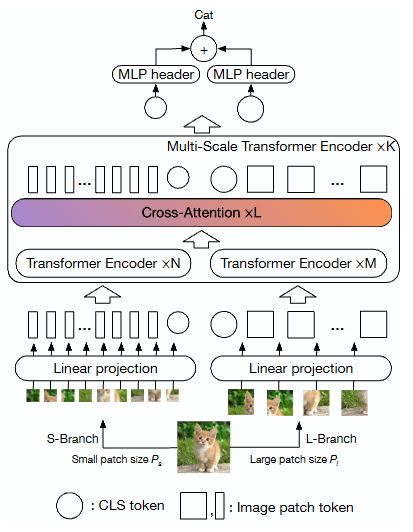

</div>
This whole block (Transformer → Cross-Attention) is repeated **K** times as the **Multi-Scale Encoder**.

### Cross-Attention Module

The key insight: the **CLS token** of one branch attends to the **patch tokens** of the other branch.

For the large branch (similarly for small, with swapped indices):

$$\mathbf{x}'^l = \left[f^l(\mathbf{x}^l_{\text{cls}}) \;\|\; \mathbf{x}^s_{\text{patch}}\right]$$

$$\mathbf{y}^l_{\text{cls}} = f^l(\mathbf{x}^l_{\text{cls}}) + \text{MCA}\left(\text{LN}\left([f^l(\mathbf{x}^l_{\text{cls}}) \;\|\; \mathbf{x}^s_{\text{patch}}]\right)\right)$$

$$\mathbf{z}^l = \left[g^l(\mathbf{y}^l_{\text{cls}}) \;\|\; \mathbf{x}^l_{\text{patch}}\right]$$

Where $f^l(\cdot)$ and $g^l(\cdot)$ are linear projections for dimension alignment.

**Why is this efficient?** Only the CLS token (1 token) serves as the query — so the attention map is linear in the number of patches, not quadratic!

In [ ]:
class ProjectInOut(nn.Module):
    """
    Wraps a layer and handles dimension mismatch between branches.
    Projects from dim_outer -> dim_inner before fn, then back to dim_outer.
    """
    def __init__(self, dim_outer, dim_inner, fn):
        super().__init__()
        self.fn = fn
        need_projection = (dim_outer != dim_inner)
        self.project_in  = nn.Linear(dim_outer, dim_inner) if need_projection else nn.Identity()
        self.project_out = nn.Linear(dim_inner, dim_outer) if need_projection else nn.Identity()

    def forward(self, x, *args, **kwargs):
        x = self.project_in(x)
        out = self.fn(x, *args, **kwargs)
        return self.project_out(out)

In [ ]:
class CrossTransformer(nn.Module):
    """
    Cross-Attention module: the CLS token of each branch attends to the
    patch tokens of the *other* branch (bidirectional cross-attention).
    """
    def __init__(self, sm_dim, lg_dim, depth, heads, dim_head, dropout):
        super().__init__()
        self.layers = nn.ModuleList([])
        for _ in range(depth):
            self.layers.append(nn.ModuleList([
                # Small CLS (sm_dim) attends to Large patches (lg_dim)
                ProjectInOut(sm_dim, lg_dim,
                             PreNorm(lg_dim, Attention(lg_dim, heads=heads,
                                                       dim_head=dim_head, dropout=dropout))),
                # Large CLS (lg_dim) attends to Small patches (sm_dim)
                ProjectInOut(lg_dim, sm_dim,
                             PreNorm(sm_dim, Attention(sm_dim, heads=heads,
                                                       dim_head=dim_head, dropout=dropout)))
            ]))

    def forward(self, sm_tokens, lg_tokens):
        # Split CLS tokens from patch tokens
        (sm_cls, sm_patches), (lg_cls, lg_patches) = (
            (sm_tokens[:, :1], sm_tokens[:, 1:]),
            (lg_tokens[:, :1], lg_tokens[:, 1:])
        )

        for sm_to_lg, lg_to_sm in self.layers:
            # Small CLS queries Large patches (kv_include_self=True prepends CLS to patches)
            sm_cls = sm_cls + sm_to_lg(sm_cls, context=lg_patches, kv_include_self=True)
            # Large CLS queries Small patches
            lg_cls = lg_cls + lg_to_sm(lg_cls, context=sm_patches, kv_include_self=True)

        # Reconstruct full token sequences
        sm_tokens = torch.cat((sm_cls, sm_patches), dim=1)
        lg_tokens = torch.cat((lg_cls, lg_patches), dim=1)
        return sm_tokens, lg_tokens

In [ ]:
class MultiScaleEncoder(nn.Module):
    """
    Stacks K rounds of: [SmallTransformer | LargeTransformer] -> CrossAttention
    """
    def __init__(self, *, depth, sm_dim, lg_dim, sm_enc_params, lg_enc_params,
                 cross_attn_heads, cross_attn_dim_head, cross_attn_depth, dropout):
        super().__init__()
        self.layers = nn.ModuleList([])
        for _ in range(depth):
            self.layers.append(nn.ModuleList([
                Transformer(dim=sm_dim, dropout=dropout, **sm_enc_params),
                Transformer(dim=lg_dim, dropout=dropout, **lg_enc_params),
                CrossTransformer(sm_dim=sm_dim, lg_dim=lg_dim,
                                 depth=cross_attn_depth,
                                 heads=cross_attn_heads,
                                 dim_head=cross_attn_dim_head,
                                 dropout=dropout)
            ]))

    def forward(self, sm_tokens, lg_tokens):
        for sm_enc, lg_enc, cross_attn in self.layers:
            sm_tokens = sm_enc(sm_tokens)
            lg_tokens = lg_enc(lg_tokens)
            sm_tokens, lg_tokens = cross_attn(sm_tokens, lg_tokens)
        return sm_tokens, lg_tokens

In [ ]:
class CrossViT(nn.Module):
    """
    Cross-Attention Multi-Scale Vision Transformer (CrossViT).
    Two branches with different patch sizes are processed in parallel
    and fused via cross-attention. Final logits = sm_logits + lg_logits.
    """
    def __init__(self, *, image_size, num_classes, sm_dim, lg_dim,
                 sm_patch_size=12, sm_enc_depth=1, sm_enc_heads=8,
                 sm_enc_mlp_dim=2048, sm_enc_dim_head=64,
                 lg_patch_size=16, lg_enc_depth=4, lg_enc_heads=8,
                 lg_enc_mlp_dim=2048, lg_enc_dim_head=64,
                 cross_attn_depth=2, cross_attn_heads=8, cross_attn_dim_head=64,
                 depth=3, dropout=0.1, emb_dropout=0.1):
        super().__init__()
        # Two patch embedders at different scales
        self.sm_image_embedder = ImageEmbedder(dim=sm_dim, image_size=image_size,
                                               patch_size=sm_patch_size, dropout=emb_dropout)
        self.lg_image_embedder = ImageEmbedder(dim=lg_dim, image_size=image_size,
                                               patch_size=lg_patch_size, dropout=emb_dropout)
        # Multi-scale encoder
        self.multi_scale_encoder = MultiScaleEncoder(
            depth=depth, sm_dim=sm_dim, lg_dim=lg_dim,
            cross_attn_heads=cross_attn_heads,
            cross_attn_dim_head=cross_attn_dim_head,
            cross_attn_depth=cross_attn_depth,
            sm_enc_params=dict(depth=sm_enc_depth, heads=sm_enc_heads,
                               mlp_dim=sm_enc_mlp_dim, dim_head=sm_enc_dim_head),
            lg_enc_params=dict(depth=lg_enc_depth, heads=lg_enc_heads,
                               mlp_dim=lg_enc_mlp_dim, dim_head=lg_enc_dim_head),
            dropout=dropout
        )
        # Separate classification heads
        self.sm_mlp_head = nn.Sequential(nn.LayerNorm(sm_dim), nn.Linear(sm_dim, num_classes))
        self.lg_mlp_head = nn.Sequential(nn.LayerNorm(lg_dim), nn.Linear(lg_dim, num_classes))

    def forward(self, img):
        sm_tokens = self.sm_image_embedder(img)
        lg_tokens = self.lg_image_embedder(img)
        sm_tokens, lg_tokens = self.multi_scale_encoder(sm_tokens, lg_tokens)
        # Use CLS token (index 0) for classification
        sm_logits = self.sm_mlp_head(sm_tokens[:, 0])
        lg_logits = self.lg_mlp_head(lg_tokens[:, 0])
        return sm_logits + lg_logits  # sum of branch logits


# --- Sanity check ---
cvit = CrossViT(
    image_size=32, num_classes=10, sm_dim=64, lg_dim=128,
    sm_patch_size=8, sm_enc_depth=2, sm_enc_heads=8, sm_enc_mlp_dim=128, sm_enc_dim_head=64,
    lg_patch_size=16, lg_enc_depth=2, lg_enc_heads=8, lg_enc_mlp_dim=128, lg_enc_dim_head=64,
    cross_attn_depth=2, cross_attn_heads=8, cross_attn_dim_head=64,
    depth=3, dropout=0.1, emb_dropout=0.1
)

out = cvit(dummy)
print(f"Input:  {dummy.shape}")
print(f"Output: {out.shape}   (expected: [4, 10])")
n_params = sum(p.numel() for p in cvit.parameters() if p.requires_grad)
print(f"CrossViT parameters: {n_params:,}")

### 3.1 Train CrossViT on CIFAR-10

In [ ]:
cvit_model = CrossViT(
    image_size=32, num_classes=10, sm_dim=64, lg_dim=128,
    sm_patch_size=8, sm_enc_depth=2, sm_enc_heads=8, sm_enc_mlp_dim=128, sm_enc_dim_head=64,
    lg_patch_size=16, lg_enc_depth=2, lg_enc_heads=8, lg_enc_mlp_dim=128, lg_enc_dim_head=64,
    cross_attn_depth=2, cross_attn_heads=8, cross_attn_dim_head=64,
    depth=3, dropout=0.1, emb_dropout=0.1
)

history_cvit, test_acc_cvit = run_training(
    cvit_model, trainloader, valloader, testloader,
    epochs=10, lr=0.003, momentum=0.9,
    save_path='models/checkpoint_cvit.pt'
)

### 3.2 Compare Models

In [ ]:
# Plot comparison
plt.figure(figsize=(8, 4))
plt.plot(history_vit['val_acc'],  marker='o', label='ViT')
plt.plot(history_cvit['val_acc'], marker='s', label='CrossViT')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.title('ViT vs CrossViT on CIFAR-10')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Final Test Accuracy — ViT: {test_acc_vit:.1f}%  |  CrossViT: {test_acc_cvit:.1f}%")

---

## Exercise 1.4 (Optional) — Visualizing Attention Maps

### What is the model looking at?

One advantage of ViT over CNNs is the interpretability of attention maps. We can inspect **which patches the CLS token attends to most** in the last transformer layer — these are the regions that most influence the classification decision.

**Procedure:**
1. Run a forward pass and retrieve the stored attention map from the last attention layer
2. Extract the row corresponding to the CLS token (index 0): `attn[0, :, 0, 1:]` → shape `[heads, n_patches]`
3. Average over heads → shape `[n_patches]`
4. Reshape to a 2D grid (e.g., 4×4) and upsample to image size
5. Overlay as a heatmap on the original image

In [ ]:
def visualize_attention(model, image_tensor, label_name, model_name='ViT', patch_size=8, image_size=32):
    """
    Visualize the CLS-token attention heatmap for a single image.
    
    Args:
        model: trained ViT or CrossViT (must have .attn stored after forward)
        image_tensor: normalized image tensor [C, H, W]
        label_name: string class label
        model_name: string for plot title
        patch_size: patch size used in this branch
        image_size: image resolution
    """
    model.eval()
    img_batch = image_tensor.unsqueeze(0)  # [1, C, H, W]

    with torch.no_grad():
        _ = model(img_batch)

    # Retrieve last attention layer
    if model_name == 'ViT':
        attn_map = model.transformer.layers[-1][0].fn.attn  # [1, heads, n+1, n+1]
    else:  # CrossViT — use small branch
        sm_transformer = model.multi_scale_encoder.layers[-1][0]
        attn_map = sm_transformer.layers[-1][0].fn.attn

    if attn_map is None:
        print("No attention map found. Did you run a forward pass?")
        return

    # CLS token attention to all patch tokens: [heads, n_patches]
    attn_cls = attn_map[0, :, 0, 1:]   # [H, N]
    avg_attn  = attn_cls.mean(dim=0)    # [N]

    patch_grid = image_size // patch_size
    attn_grid  = avg_attn.reshape(patch_grid, patch_grid)   # e.g. [4, 4]

    # Upsample to image size
    heatmap = F.interpolate(
        attn_grid.unsqueeze(0).unsqueeze(0),
        size=(image_size, image_size), mode='bilinear', align_corners=False
    ).squeeze()

    img_display = unnormalize(image_tensor).permute(1, 2, 0).numpy()

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
    ax1.imshow(img_display); ax1.set_title(f'Input ({label_name})'); ax1.axis('off')
    ax2.imshow(heatmap.numpy(), cmap='jet'); ax2.set_title('Attention Map'); ax2.axis('off')
    ax3.imshow(img_display)
    ax3.imshow(heatmap.numpy(), alpha=0.5, cmap='jet')
    ax3.set_title(f'{model_name} Attention Overlay'); ax3.axis('off')
    plt.tight_layout()
    plt.show()

    max_idx = avg_attn.argmax().item()
    print(f"Most attended patch index: {max_idx} "
          f"(row {max_idx // patch_grid}, col {max_idx % patch_grid})")

In [ ]:
# Visualize attention for a few test images
for img_idx in [0, 5, 12]:
    img_t, lbl = testset[img_idx]
    print(f"\nImage {img_idx} — Class: {CLASSES[lbl]}")
    visualize_attention(vit_model, img_t, CLASSES[lbl], model_name='ViT')

In [ ]:
# Optionally compare ViT vs CrossViT attention on the same image
img_t, lbl = testset[0]
print("ViT Attention:")
visualize_attention(vit_model,  img_t, CLASSES[lbl], model_name='ViT')
print("CrossViT Attention (small branch):")
visualize_attention(cvit_model, img_t, CLASSES[lbl], model_name='CrossViT')

---

## Summary and Discussion

### Results

| Model | Parameters | Test Accuracy |
|-------|-----------|---------------|
| ResNet-18 | ~11M | — |
| ViT (small) | ~200K | — |
| CrossViT (small) | ~1.5M | — |

*(Fill in your numbers after training!)*

### Key Takeaways

1. **ViT on small datasets**: Pure transformers trained from scratch on CIFAR-10 (a small dataset) typically underperform ResNets. ViT lacks the inductive biases of CNNs (locality, translation equivariance), so it needs more data or pretraining to shine.

2. **CrossViT's advantage**: By combining two scales, CrossViT can capture both fine-grained and coarse features. The cross-attention fusion is *linear* in cost (only the CLS token is the query), making it efficient.

3. **Attention maps**: The CLS token attention in the last layer often highlights semantically meaningful regions — the object of interest — showing that ViT does learn to "look" at the right places.

4. **Scaling**: ViT truly excels at large scale (ImageNet-21k, JFT-300M). CrossViT improves DeiT by ~1-2% on ImageNet without large pretraining datasets.

### Further Experiments to Try
- Increase the number of epochs (try 50–100)
- Use a learning rate scheduler (e.g., cosine annealing)
- Try different patch sizes (4, 16) and observe the trade-off
- Use AdamW optimizer instead of SGD
- Add stronger augmentation (CutMix, MixUp, RandAugment)

In [ ]:
# Final model evaluation from saved checkpoints
def load_and_evaluate(model, checkpoint_path, testloader, criterion, device):
    if os.path.exists(checkpoint_path):
        ckpt = torch.load(checkpoint_path, weights_only=True)
        model.load_state_dict(ckpt['model_state_dict'])
        print(f"Loaded from epoch {ckpt.get('epoch')} (val acc: {ckpt.get('accuracy', '?'):.2f}%)")
        return evaluate(model, testloader, criterion, device, split="Test")
    else:
        print(f"Checkpoint not found: {checkpoint_path}")
        return None

criterion = nn.CrossEntropyLoss(reduction="sum")
vit_final  = ViT(image_size=32, patch_size=8, num_classes=10, dim=64,
                 depth=2, heads=8, mlp_dim=128, dropout=0.1, emb_dropout=0.1).to(device)
cvit_final = CrossViT(image_size=32, num_classes=10, sm_dim=64, lg_dim=128,
                      sm_patch_size=8, sm_enc_depth=2, sm_enc_heads=8, sm_enc_mlp_dim=128, sm_enc_dim_head=64,
                      lg_patch_size=16, lg_enc_depth=2, lg_enc_heads=8, lg_enc_mlp_dim=128, lg_enc_dim_head=64,
                      cross_attn_depth=2, cross_attn_heads=8, cross_attn_dim_head=64,
                      depth=3, dropout=0.1, emb_dropout=0.1).to(device)

print("ViT:")
load_and_evaluate(vit_final,  'models/checkpoint_vit.pt',  testloader, criterion, device)
print("\nCrossViT:")
load_and_evaluate(cvit_final, 'models/checkpoint_cvit.pt', testloader, criterion, device)